<a href="https://colab.research.google.com/github/priyal6/General-llm/blob/main/embedding_benchmark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Embedding Model Benchmark
Measures **latency** (ms per sentence) and **throughput** (sentences/sec) across open-source and API embedding models.

| Section | Models covered |
|---|---|
| 1. Install & imports | all |
| 2. Benchmark harness | reusable |
| 3. Open-source models | SBERT, E5, BGE, GTE, Qwen, Gemma, CLIP |
| 4. API models | OpenAI, Cohere |
| 5. Results table | all models side-by-side |

In [ ]:

%pip install -q sentence-transformers transformers torch torchvision \
             openai cohere Pillow requests pandas tabulate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 39.6 MB/s eta 0:00:00


In [ ]:

import time
import os
import warnings
import numpy as np
import pandas as pd
from IPython.display import display, HTML

warnings.filterwarnings("ignore")

SENTENCES = [
    "Machine learning is a branch of artificial intelligence.",
    "Retrieval-augmented generation improves LLM accuracy.",
    "Semantic search finds conceptually similar documents.",
    "Vector databases store high-dimensional embeddings efficiently.",
    "Multilingual models handle text across many languages.",
    "Transformer architectures revolutionised natural language processing.",
    "Cosine similarity measures the angle between two vectors.",
    "Fine-tuning adapts a pre-trained model to a specific domain.",
    "Embedding quality directly affects downstream retrieval accuracy.",
    "Open-source models offer full control over deployment infrastructure.",
]

WARMUP_RUNS = 2   # discarded
BENCH_RUNS  = 5   # averaged

results: list[dict] = []  # filled by each cell below


def benchmark(name: str, encode_fn, sentences=SENTENCES,
              warmup=WARMUP_RUNS, runs=BENCH_RUNS,
              model_type="open-source", modality="text",
              dims: int | None = None) -> dict:
    """Time encode_fn(sentences) over `runs` trials after `warmup` warm-ups.
    Returns a results dict and appends it to the global `results` list.
    """
    # warm-up
    for _ in range(warmup):
        encode_fn(sentences)

    latencies_ms = []
    emb_dims = dims
    for _ in range(runs):
        t0 = time.perf_counter()
        vecs = encode_fn(sentences)
        latencies_ms.append((time.perf_counter() - t0) * 1000)
        if emb_dims is None and vecs is not None:
            arr = np.array(vecs)
            emb_dims = arr.shape[-1] if arr.ndim > 1 else len(vecs[0])

    mean_ms   = float(np.mean(latencies_ms))
    std_ms    = float(np.std(latencies_ms))
    per_ms    = mean_ms / len(sentences)        # ms per sentence
    throughput = 1000 / per_ms                  # sentences/sec

    row = dict(
        Model        = name,
        Type         = model_type,
        Modality     = modality,
        Dims         = emb_dims,
        Total_ms     = round(mean_ms, 1),
        Std_ms       = round(std_ms, 1),
        Per_sent_ms  = round(per_ms, 2),
        Throughput   = round(throughput, 1),
    )
    results.append(row)
    print(f"  {name:<22} {mean_ms:>8.1f} ms total  "
          f"({per_ms:.2f} ms/sent  |  {throughput:.0f} sent/s)")
    return row


print("Harness ready. Corpus:", len(SENTENCES), "sentences.")

Harness ready. Corpus: 10 sentences.


---
## 3. Open-source models

In [ ]:
from sentence_transformers import SentenceTransformer

print("Loading SBERT (all-MiniLM-L6-v2)...")
sbert = SentenceTransformer("all-MiniLM-L6-v2")

benchmark(
    name       = "SBERT (MiniLM-L6-v2)",
    encode_fn  = lambda s: sbert.encode(s, show_progress_bar=False),
    model_type = "Open-source",
)

Loading SBERT (all-MiniLM-L6-v2)...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

  SBERT (MiniLM-L6-v2)       83.6 ms total  (8.36 ms/sent  |  120 sent/s)


{'Model': 'SBERT (MiniLM-L6-v2)',
 'Type': 'Open-source',
 'Modality': 'text',
 'Dims': 384,
 'Total_ms': 83.6,
 'Std_ms': 2.4,
 'Per_sent_ms': 8.36,
 'Throughput': 119.6}

In [ ]:

print("Loading E5 (intfloat/e5-base-v2)...")
e5 = SentenceTransformer("intfloat/e5-base-v2")

# E5 requires 'passage: ' prefix for documents
e5_sentences = [f"passage: {s}" for s in SENTENCES]

benchmark(
    name       = "E5 (e5-base-v2)",
    encode_fn  = lambda s: e5.encode(s, normalize_embeddings=True, show_progress_bar=False),
    sentences  = e5_sentences,
    model_type = "Open-source",
)

Loading E5 (intfloat/e5-base-v2)...


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/650 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

  E5 (e5-base-v2)           693.7 ms total  (69.37 ms/sent  |  14 sent/s)


{'Model': 'E5 (e5-base-v2)',
 'Type': 'Open-source',
 'Modality': 'text',
 'Dims': 768,
 'Total_ms': 693.7,
 'Std_ms': 12.0,
 'Per_sent_ms': 69.37,
 'Throughput': 14.4}

In [ ]:

print("Loading BGE (BAAI/bge-base-en-v1.5)...")
bge = SentenceTransformer("BAAI/bge-base-en-v1.5")

benchmark(
    name       = "BGE (bge-base-en-v1.5)",
    encode_fn  = lambda s: bge.encode(s, normalize_embeddings=True, show_progress_bar=False),
    model_type = "Open-source",
)

Loading BGE (BAAI/bge-base-en-v1.5)...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

  BGE (bge-base-en-v1.5)    630.6 ms total  (63.06 ms/sent  |  16 sent/s)


{'Model': 'BGE (bge-base-en-v1.5)',
 'Type': 'Open-source',
 'Modality': 'text',
 'Dims': 768,
 'Total_ms': 630.6,
 'Std_ms': 20.5,
 'Per_sent_ms': 63.06,
 'Throughput': 15.9}

In [ ]:
print("Loading GTE (thenlper/gte-base)...")
gte = SentenceTransformer("thenlper/gte-base")

benchmark(
    name       = "GTE (gte-base)",
    encode_fn  = lambda s: gte.encode(s, normalize_embeddings=True, show_progress_bar=False),
    model_type = "Open-source",
)

Loading GTE (thenlper/gte-base)...


modules.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/618 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

  GTE (gte-base)           4296.3 ms total  (429.63 ms/sent  |  2 sent/s)


{'Model': 'GTE (gte-base)',
 'Type': 'Open-source',
 'Modality': 'text',
 'Dims': 768,
 'Total_ms': 4296.3,
 'Std_ms': 1407.9,
 'Per_sent_ms': 429.63,
 'Throughput': 2.3}

In [ ]:

from transformers import CLIPTokenizer, CLIPTextModel
import torch
print("Loading CLIP (openai/clip-vit-base-patch32) — text branch...")
clip_tok = CLIPTokenizer.from_pretrained("openai/clip-vit-base-patch32")
clip_mod = CLIPTextModel.from_pretrained("openai/clip-vit-base-patch32").eval()


def clip_encode(sentences):
    inp = clip_tok(sentences, return_tensors="pt",
                  padding=True, truncation=True, max_length=77)
    with torch.no_grad():
        out = clip_mod(**inp)
    return out.pooler_output.numpy()  # [CLS] pooled


benchmark(
    name       = "CLIP (ViT-B/32 text)",
    encode_fn  = clip_encode,
    model_type = "Open-source",
    modality   = "text + image",
    dims       = 512,
)

Loading CLIP (openai/clip-vit-base-patch32) — text branch...


tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
vision_model.embeddings.class_embedding                        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.

  CLIP (ViT-B/32 text)      568.5 ms total  (56.85 ms/sent  |  18 sent/s)


{'Model': 'CLIP (ViT-B/32 text)',
 'Type': 'Open-source',
 'Modality': 'text + image',
 'Dims': 512,
 'Total_ms': 568.5,
 'Std_ms': 107.5,
 'Per_sent_ms': 56.85,
 'Throughput': 17.6}

---
## 4. API models (requires keys)

In [ ]:
from openai import OpenAI
from google.colab import userdata

OPENAI_KEY = userdata.get("OPENAI_API_KEY")

if not OPENAI_KEY:
    print(" OPENAI_API_KEY not set")
else:
    oa = OpenAI(api_key=OPENAI_KEY)

    def openai_encode(sentences):
        resp = oa.embeddings.create(
            model="text-embedding-3-small",
            input=sentences,
        )
        return [item.embedding for item in resp.data]

    benchmark(
        name       = "OpenAI (text-emb-3-small)",
        encode_fn  = openai_encode,
        model_type = "Closed-source (API)",
        dims       = 1536,
    )

  OpenAI (text-emb-3-small)    278.5 ms total  (27.85 ms/sent  |  36 sent/s)


---
## 5. Results table

In [ ]:
df = pd.DataFrame(results).rename(columns={
    "Total_ms":    "Total (ms)",
    "Std_ms":      "± std (ms)",
    "Per_sent_ms": "ms / sentence",
    "Throughput":  "Sentences / sec",
})

df_sorted = df.sort_values("ms / sentence")

def color_ms(val):
    """Green = fast, red = slow (relative to min/max in column)."""
    col = df_sorted["ms / sentence"]
    lo, hi = col.min(), col.max()
    norm = (val - lo) / (hi - lo + 1e-9)
    r = int(norm * 200)
    g = int((1 - norm) * 160)
    return f"color: rgb({r},{g},60); font-weight:600"


styled = (
    df_sorted.style
    .applymap(color_ms, subset=["ms / sentence"])
    .format({
        "Total (ms)":     "{:.1f}",
        "± std (ms)":     "{:.1f}",
        "ms / sentence":  "{:.2f}",
        "Sentences / sec": "{:.0f}",
    })
    .set_table_styles([
        {"selector": "thead th",
         "props": [("background", "#1a1a2e"), ("color", "#e0e0ff"),
                   ("padding", "8px 12px"), ("font-size", "12px"),
                   ("letter-spacing", ".05em"), ("border-bottom", "2px solid #4a4a8a")]},
        {"selector": "tbody tr:nth-child(even)",
         "props": [("background", "#f5f5ff")]},
        {"selector": "tbody td",
         "props": [("padding", "7px 12px"), ("font-size", "13px")]},
        {"selector": "tbody tr:hover",
         "props": [("background", "#e8e8ff")]},
    ])
    .set_caption("Embedding model latency benchmark — sorted by ms / sentence (ascending = faster)")
    .hide(axis="index")
)

display(styled)


fastest = df_sorted.iloc[0]
slowest = df_sorted.iloc[-1]
print(f"\nFastest : {fastest['Model']}  —  {fastest['ms / sentence']:.2f} ms/sent")
print(f"Slowest : {slowest['Model']}  —  {slowest['ms / sentence']:.2f} ms/sent")
print(f"Speedup : {slowest['ms / sentence'] / fastest['ms / sentence']:.1f}×")

Model,Type,Modality,Dims,Total (ms),± std (ms),ms / sentence,Sentences / sec
SBERT (MiniLM-L6-v2),Open-source,text,384,83.6,2.4,8.36,120
OpenAI (text-emb-3-small),Closed-source (API),text,1536,278.5,78.6,27.85,36
CLIP (ViT-B/32 text),Open-source,text + image,512,568.5,107.5,56.85,18
BGE (bge-base-en-v1.5),Open-source,text,768,630.6,20.5,63.06,16
E5 (e5-base-v2),Open-source,text,768,693.7,12.0,69.37,14
OpenAI (text-emb-3-small),Closed-source (API),text,1536,911.8,332.4,91.18,11
GTE (gte-base),Open-source,text,768,4296.3,1407.9,429.63,2



Fastest : SBERT (MiniLM-L6-v2)  —  8.36 ms/sent
Slowest : GTE (gte-base)  —  429.63 ms/sent
Speedup : 51.4×


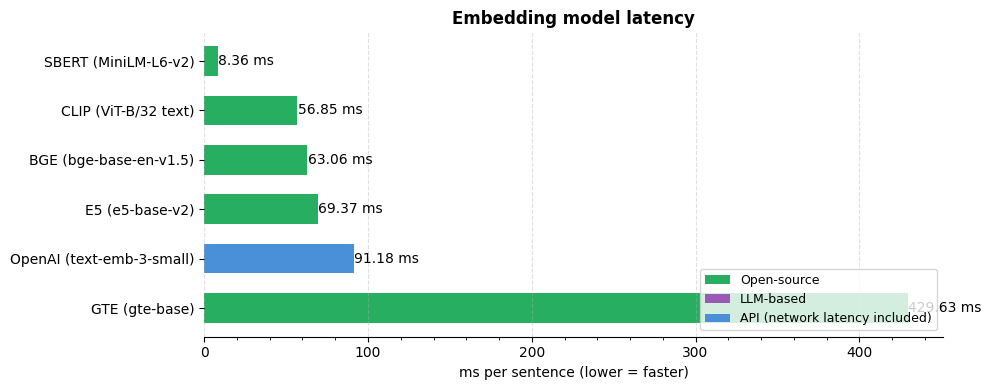

Chart saved to embedding_latency.png


In [ ]:

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(10, 4))

colors = [
    "#4a90d9" if "API" in t
    else "#9b59b6" if "LLM" in t
    else "#27ae60"
    for t in df_sorted["Type"]
]

bars = ax.barh(df_sorted["Model"], df_sorted["ms / sentence"],
               color=colors, edgecolor="none", height=0.6)

for bar, val in zip(bars, df_sorted["ms / sentence"]):
    ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{val:.2f} ms", va="center", fontsize=10)

ax.set_xlabel("ms per sentence (lower = faster)")
ax.set_title("Embedding model latency", fontweight="bold")
ax.invert_yaxis()
ax.spines[["top", "right", "left"]].set_visible(False)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(axis="x", linestyle="--", alpha=0.4)

# legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#27ae60", label="Open-source"),
    Patch(facecolor="#9b59b6", label="LLM-based"),
    Patch(facecolor="#4a90d9", label="API (network latency included)"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=9)

plt.tight_layout()
plt.savefig("embedding_latency.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved to embedding_latency.png")